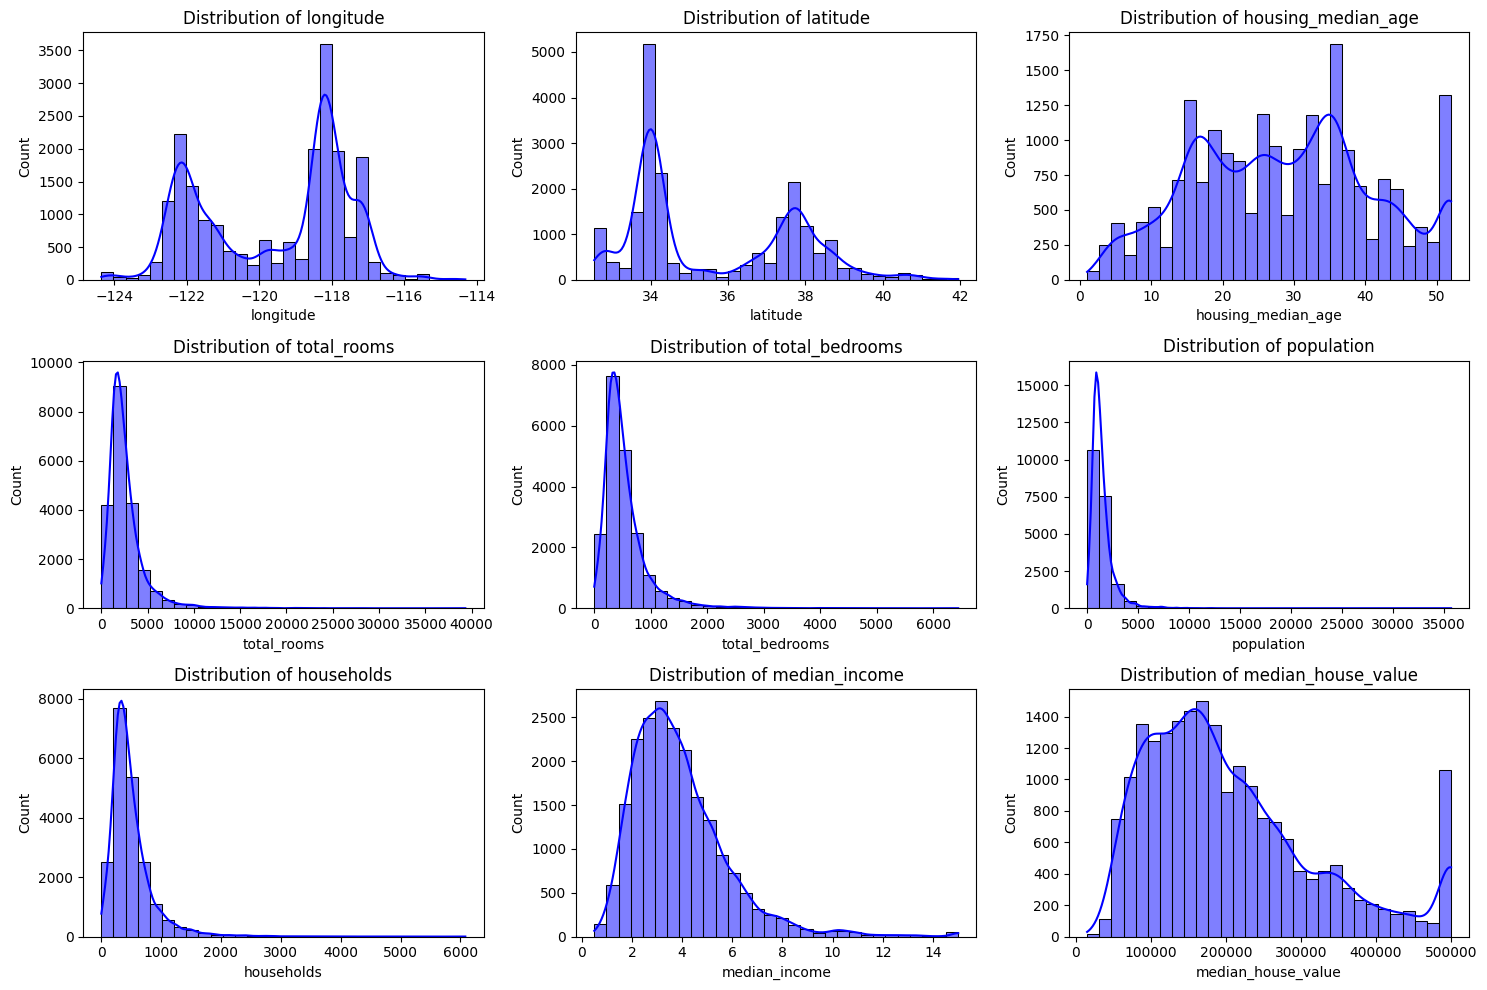

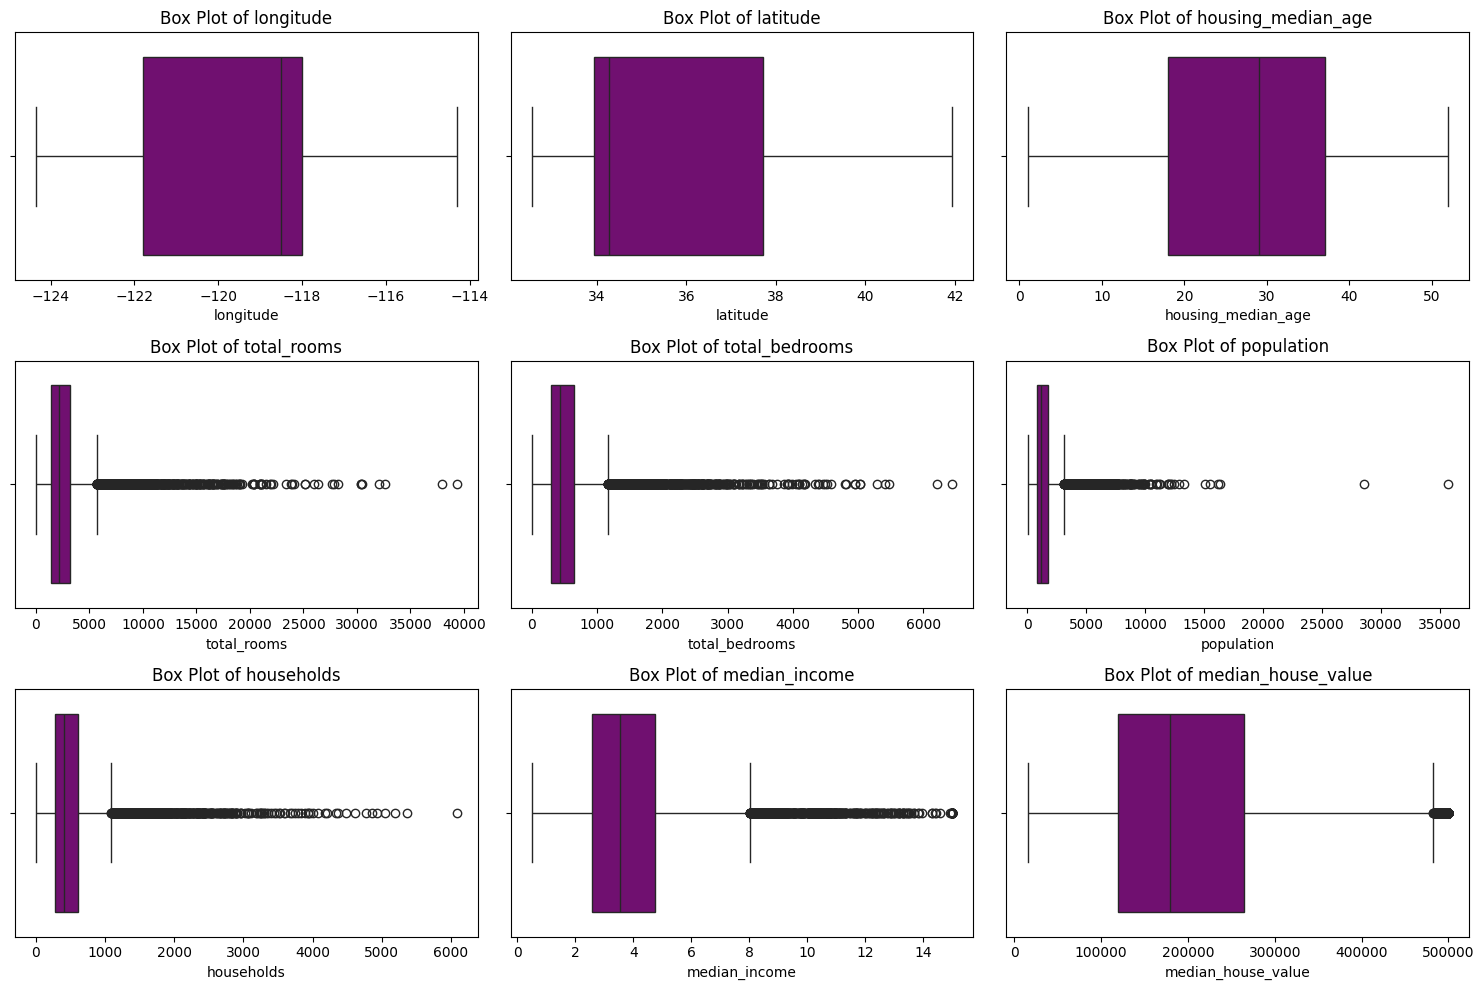

Outliers Detection:
longitude: 0 outliers
latitude: 0 outliers
housing_median_age: 0 outliers
total_rooms: 1287 outliers
total_bedrooms: 1271 outliers
population: 1196 outliers
households: 1220 outliers
median_income: 681 outliers
median_house_value: 1071 outliers

Dataset Summary:
          longitude      latitude  housing_median_age   total_rooms  \
count  20640.000000  20640.000000        20640.000000  20640.000000   
mean    -119.569704     35.631861           28.639486   2635.763081   
std        2.003532      2.135952           12.585558   2181.615252   
min     -124.350000     32.540000            1.000000      2.000000   
25%     -121.800000     33.930000           18.000000   1447.750000   
50%     -118.490000     34.260000           29.000000   2127.000000   
75%     -118.010000     37.710000           37.000000   3148.000000   
max     -114.310000     41.950000           52.000000  39320.000000   

       total_bedrooms    population    households  median_income  \
count    

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load the Housing dataset from CSV file
housing_df = pd.read_csv("housing.csv")

# Step 2: Select numerical features
numerical_features = housing_df.select_dtypes(include=[np.number]).columns

# Step 3: Create histograms for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.histplot(housing_df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
plt.tight_layout()
plt.show()

# Step 4: Generate box plots for numerical features
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i + 1)
    sns.boxplot(x=housing_df[feature], color='purple')
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# Step 5: Identify outliers using the IQR method
print("Outliers Detection:")
outliers_summary = {}

for feature in numerical_features:
    Q1 = housing_df[feature].quantile(0.25)
    Q3 = housing_df[feature].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = housing_df[
        (housing_df[feature] < lower_bound) |
        (housing_df[feature] > upper_bound)
    ]

    outliers_summary[feature] = len(outliers)
    print(f"{feature}: {len(outliers)} outliers")

# Step 6: Dataset summary
print("\nDataset Summary:")
print(housing_df.describe())
